In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.simplefilter("ignore")


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving True.csv to True (1).csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Fake.csv to Fake.csv


In [ ]:
df_fake = pd.read_csv("Fake.csv")
df_real = pd.read_csv("True.csv")


In [ ]:
df_fake["label"] = 0  # Fake News
df_real["label"] = 1  # Real News

df = pd.concat([df_fake, df_real], axis=0)
df = df.sample(frac=1).reset_index(drop=True)  # Shuffle dataset
df.head()


,title,text,subject,date,label
0,Yemen humanitarian situation likely to worsen ...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,worldnews,"December 6, 2017",1
1,(VIDEO) ANTI-TERROR EXPERT WARNS OF RISK IN CL...,"As Obama pushes to close GITMO, two former det...",politics,"Jul 25, 2015",0
2,Australian publisher delays book alleging Chin...,BEIJING (Reuters) - One of Australia s largest...,worldnews,"November 13, 2017",1
3,"In German rustbelt, Merkel challenger's social...","DUESSELDORF/DUISBURG, Germany (Reuters) - The ...",worldnews,"September 18, 2017",1
4,TRUMP GETS HAMMERED [Video] For Not Condemning...,"Yeah, because taking Trump down is more import...",politics,"Sep 18, 2015",0


In [ ]:
nltk.download('stopwords')
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text)  # Remove extra spaces
    text = ' '.join(word for word in text.split() if word not in stop_words)  # Remove stopwords
    return text

df["text"] = df["title"] + " " + df["text"]  # Combine title and content
df["text"] = df["text"].apply(clean_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df["text"])
y = df["label"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

Accuracy: 0.9885300668151448

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      4782
           1       0.98      0.99      0.99      4198

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



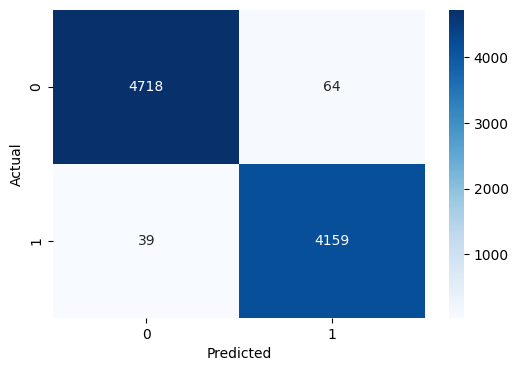

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
def predict_news(news):
    cleaned_news = clean_text(news)
    vectorized_news = tfidf_vectorizer.transform([cleaned_news])
    prediction = model.predict(vectorized_news)
    return "Real News" if prediction == 1 else "Fake News"

# Test with a sample news article
news = "Breaking: The stock market crashes due to unforeseen circumstances!"
print("Prediction:", predict_news(news))


Prediction: Fake News


In [ ]:
news1 = "NASA successfully lands a new rover on Mars, marking a significant milestone in space exploration."
print("Prediction:", predict_news(news1))


Prediction: Fake News


In [ ]:
news2 = "The World Health Organization announces new guidelines to prevent the spread of infectious diseases."
print("Prediction:", predict_news(news2))


Prediction: Fake News


In [ ]:
news3 = "Government officials sign a new trade agreement to boost economic growth in the country."
print("Prediction:", predict_news(news3))


Prediction: Real News


In [ ]:
news4 = "Scientists confirm that the moon is actually made of cheese, shocking the entire world."
print("Prediction:", predict_news(news4))



Prediction: Fake News


In [ ]:
news5 = "Breaking: Aliens have landed in New York and are demanding to meet world leaders!"
print("Prediction:", predict_news(news5))


Prediction: Fake News
